In [ ]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import load_img_natraster, print_wise,  get_triu_perms
from general_utils.II import compare_similarity_metrics


In [39]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name = 'paul'
    date = '230204'
    new_fs: int = 100 # Hz
    channels_idx = np.arange(20)
    brain_area = "AIT"
    new_fs = 100
    RDM_metric_A: str = 'cosine_cnt'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()


In [32]:
ba_raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, brain_area=cfg.brain_area, new_fs=cfg.new_fs)

In [29]:
get_triu_perms([cfg.RDM_metric_A, cfg.RDM_metric_B, "mahalanobis", "euclidean"])

[('cosine', 'cosine_cnt'),
 ('mahalanobis', 'cosine_cnt'),
 ('mahalanobis', 'cosine'),
 ('euclidean', 'cosine_cnt'),
 ('euclidean', 'cosine'),
 ('euclidean', 'mahalanobis')]

In [ ]:
# no parallelization, just one process, add the possibility to pass the object (2 RDM timeseries might not fit into memory - so could proceed column or row wise)
def compare_similarity_metrics(data: np.ndarray, metric1: str, metric2: str, k: int): 
    ii_obj = InformationImbalance(metric1, metric2, k)
    ii_obj.compute_RDM(data, "signal")
    ii_obj.compute_RDM(data, "model")
    ii_obj.compute_both_distance_ranks()
    ii_A2B, ii_B2A = ii_obj.compute_both_II()
    return ii_obj, ii_A2B, ii_B2A
# EOF


In [ ]:

def dyn_compare_similarity_metrics(paths, rank, metrics_tuple, monkey_name, date, brain_area, new_fs):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{metrics_tuple[0]}-{metrics_tuple[1]}_{monkey_name}_{date}_{brain_area}_{new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{metrics_tuple[1]}-{metrics_tuple[0]}_{monkey_name}_{date}_{brain_area}_{new_fs}Hz.npz"
    if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
    else:
        A2B_list = []
        B2A_list = []
        for idx, resp_t in enumerate(ba_raster):
            _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
            A2B_list.append(A2B)
            B2A_list.append(B2A)
        # end for idx, resp_t in enumerate(ba_raster):
        np.savez_compressed(save_name_A2B, np.stack(A2B_list))
        np.savez_compressed(save_name_B2A, np.stack(B2A_list))
    # end if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
# EOF

0

In [43]:
np.stack(A2B_list).shape

(40,)

In [ ]:
# np.savez_compressed()
print(f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{cfg.RDM_metric_A}-{cfg.RDM_metric_B}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz")

/Users/tizianocausin/livingstone_lab_local/tiziano/results/metric_comparison_cosine_cnt2cosine_three0_250313_AIT_100Hz.npz


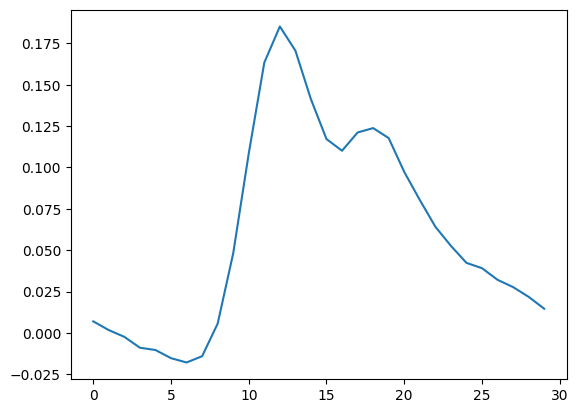

In [20]:
plt.plot(np.mean(ba_raster.get_array(), axis=(0,2)))

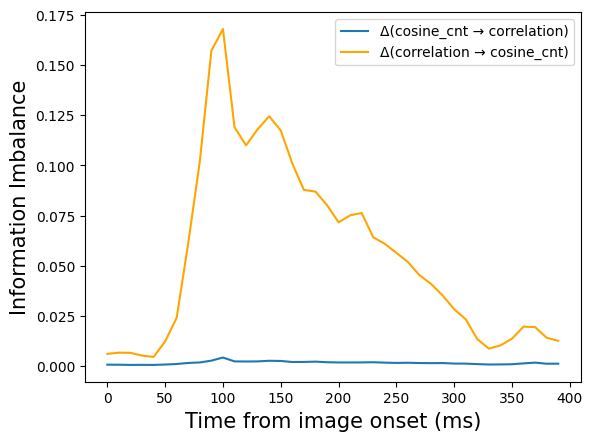

In [41]:
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()